> **NEW: troll+insult merged into a single `flaming` class** (`MERGE_TROLL_INSULT=True` in Section 2). `flaming` = troll OR insult (~50% of rows) — the two overlapping classes both models failed to separate. Set the flag `False` to reproduce the original 5-class setup.

# Bengali Multi-Label Cyberbullying Detection v8.1 (Lightweight)

Predicts 4 toxic labels (`vulgar`, `threat`, `troll`, `insult`); `neutral` is **derived**.

### What this version adds
The v8 run was healthy (val Macro-F1 peaked at ~0.724 at epoch 10) but then **overfit on a noisy
0.70-0.72 plateau**, and early stopping bets on a single spiky epoch that may not transfer to test.
v8.1 fixes that symptom:

1. **SWA (Stochastic Weight Averaging).** After the embeddings unfreeze, the weights from the
   plateau epochs are averaged into an SWA model. We then **keep whichever of {best-single, SWA}
   scores higher on validation**, so SWA can only help — it gives a flatter, more robust solution
   that usually transfers to the test set better than a single peak epoch.
2. Kept from v8: balance-preserving augmentation (distribution unchanged), lower post-unfreeze LR
   (body 0.30x, embeddings 0.05x), right-sized + regularized network, and a **multi-seed ensemble**
   (each member also uses SWA selection) as the headline result.

Also kept: split-before-augment with zero-leakage assertions, vocab from original text, Focal loss
without `pos_weight`, derived neutral, per-class threshold tuning, `nn.DataParallel` for T4 x2.

> Honest ceiling: the subjective, overlapping `troll`/`insult` labels cap a from-scratch model
> around ~0.73-0.75. SWA + ensemble target a robust best in that range; the transformer notebook is
> where ~0.80 lives.


In [1]:
# Section 1: Setup & Imports
!pip install iterative-stratification -q

import os, re, math, random, time, json, copy, gzip, warnings
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

from sklearn.metrics import (
    f1_score, classification_report, hamming_loss,
    roc_auc_score, average_precision_score
)
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

NUM_GPUS = torch.cuda.device_count()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}')
print(f'Device: {device} | GPUs available: {NUM_GPUS}')
for i in range(NUM_GPUS):
    p = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {p.name} ({p.total_memory/1e9:.1f} GB)')


PyTorch 2.10.0+cu128
Device: cuda | GPUs available: 2
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)


In [2]:
# Section 2: Configuration

class Config:
    DATA_PATH = '/kaggle/input/datasets/muhammedjunayed/bengalicyber/combined_multi_labeled_bengali_comments_balanced_13k_14k_plus_neutral_plus_threat300.csv'
    TEXT_COL = 'text'
    LABEL_COLS = ['vulgar', 'threat', 'troll', 'insult', 'neutral']
    TOXIC_COLS = ['vulgar', 'threat', 'troll', 'insult']
    NUM_OUT = 4
    MERGE_TROLL_INSULT = True   # merge troll+insult -> 'flaming' (set False for original 5-class)
    NEUTRAL_COL = 'neutral'

    MIN_WORDS = 2
    VOCAB_SIZE = 40000
    MIN_FREQ = 2
    MAX_LEN = 80

    CHAR_VOCAB_SIZE = 300
    MAX_CHAR_PER_WORD = 16
    CHAR_EMBED_DIM = 32
    CHAR_CNN_FILTERS = 64
    CHAR_KERNELS = (2, 3, 4)

    USE_PRETRAINED = True
    FASTTEXT_DIM = 300
    FREEZE_EMBEDDING = True
    UNFREEZE_AT_EPOCH = 6
    UNFREEZE_EMB_LR_FACTOR = 0.05
    UNFREEZE_BODY_LR_FACTOR = 0.30
    PROJECTION_DIM = 256

    TEST_FRAC = 0.15
    VAL_FRAC = 0.15

    CNN_FILTERS = 224
    CNN_KERNELS = (2, 3, 4)
    GRU_HIDDEN = 384
    GRU_LAYERS = 2
    FC_HIDDEN = 384
    DROPOUT_EMB = 0.45
    DROPOUT = 0.5
    NUM_DROPOUT_SAMPLES = 5

    BATCH_SIZE_PER_GPU = 64
    EPOCHS = 35
    LR = 8e-4
    WEIGHT_DECAY = 1e-3
    WARMUP_RATIO = 0.10
    GRAD_CLIP = 1.0
    LABEL_SMOOTHING = 0.05

    USE_FOCAL_LOSS = True
    FOCAL_GAMMA = 2.0
    USE_POS_WEIGHT = False

    WORD_DROPOUT_P = 0.30

    PATIENCE = 8
    DEFAULT_THRESHOLD = 0.5

    # --- SWA (NEW): average weights over the post-unfreeze plateau; keep only if it beats best-single on val ---
    USE_SWA = True
    SWA_START_OFFSET = 3          # start averaging this many epochs after the unfreeze epoch

    # --- Balance-preserving TRAIN-ONLY augmentation ---
    AUGMENT = True
    AUG_COPIES = 1

    THRESH_MIN = 0.30
    THRESH_MAX = 0.70
    THRESH_STEP = 0.02

    RUN_ENSEMBLE = True
    ENSEMBLE_SEEDS = [42, 7, 2024]

cfg = Config()
EFFECTIVE_BATCH = cfg.BATCH_SIZE_PER_GPU * max(NUM_GPUS, 1)
print(f'Effective batch size: {EFFECTIVE_BATCH} ({cfg.BATCH_SIZE_PER_GPU} x {max(NUM_GPUS,1)} GPU)')
print(f'Model predicts {cfg.NUM_OUT} toxic labels; "neutral" is derived as NOT(any toxic).')
print(f'Phases: Frozen(1-{cfg.UNFREEZE_AT_EPOCH-1}) -> Unfrozen({cfg.UNFREEZE_AT_EPOCH}-{cfg.EPOCHS}) | SWA={cfg.USE_SWA}')
print(f'Augmentation: balance-preserving ({cfg.AUG_COPIES} copy/row) | Ensemble: {cfg.RUN_ENSEMBLE} {cfg.ENSEMBLE_SEEDS}')


Effective batch size: 128 (64 x 2 GPU)
Model predicts 4 toxic labels; "neutral" is derived as NOT(any toxic).
Phases: Frozen(1-5) -> Unfrozen(6-35) | SWA=True
Augmentation: balance-preserving (1 copy/row) | Ensemble: True [42, 7, 2024]


In [3]:
# Section 3: Load + Clean + Deduplicate (on CLEANED text) + Derive neutral

data_paths = [
    cfg.DATA_PATH,
    f'/kaggle/input/datasets/muhammedjunayed/bengalicyber/{cfg.DATA_PATH}',
    f'/kaggle/input/datasets/keepsmiling15/15518-cyberbullying-bengali-cmnt/{cfg.DATA_PATH}',
    f'/kaggle/input/bengali-cyberbullying-15k/{cfg.DATA_PATH}',
    f'./{cfg.DATA_PATH}',
]
df = None
for p in data_paths:
    if os.path.exists(p):
        df = pd.read_csv(p); print(f'Loaded dataset from: {p}'); break
if df is None:
    raise FileNotFoundError(f'Dataset not found. Tried: {data_paths}')
print(f'Raw dataset: {len(df)} rows, columns: {list(df.columns)}')

for col in cfg.LABEL_COLS:
    assert col in df.columns, f'Missing column: {col}'
    df[col] = df[col].astype(int)

# --- Merge troll+insult into a single 'flaming' class (recognized cyberbullying category) ---
if getattr(cfg, 'MERGE_TROLL_INSULT', False):
    df['flaming'] = ((df['troll'] == 1) | (df['insult'] == 1)).astype(int)
    cfg.TOXIC_COLS = ['vulgar', 'threat', 'flaming']
    cfg.LABEL_COLS = ['vulgar', 'threat', 'flaming', 'neutral']
    cfg.NUM_OUT = len(cfg.TOXIC_COLS)
    print("MERGE_TROLL_INSULT=True -> classes:", cfg.LABEL_COLS, "| NUM_OUT =", cfg.NUM_OUT)

URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
HASHTAG_RE = re.compile(r'#(\w+)')
EMOJI_RE = re.compile(
    '[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF'
    '\U0001F680-\U0001F6FF\U0001F900-\U0001F9FF'
    '\U00002702-\U000027B0]+', flags=re.UNICODE)
PUNCT_RE = re.compile(r'[^\u0980-\u09FF\s]')

def clean_text(text):
    text = str(text).strip()
    text = URL_RE.sub(' ', text)
    text = MENTION_RE.sub(' ', text)
    text = HASHTAG_RE.sub(r'\1', text)
    text = EMOJI_RE.sub(' ', text)
    text = PUNCT_RE.sub(' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_text'] = df[cfg.TEXT_COL].apply(clean_text)
df['_wc'] = df['clean_text'].str.split().str.len().fillna(0)
df = df[df['_wc'] >= cfg.MIN_WORDS].copy()

before = len(df)
df = df.groupby('clean_text', as_index=False)[cfg.LABEL_COLS].max()
print(f'Deduplicated on cleaned text: {before} -> {len(df)}')

tox = df[cfg.TOXIC_COLS].sum(axis=1) > 0
df[cfg.NEUTRAL_COL] = (~tox).astype(int)
df[cfg.TEXT_COL] = df['clean_text']
df = df.reset_index(drop=True)

print('\nPer-class distribution (full, post-clean):')
for col in cfg.LABEL_COLS:
    n = int(df[col].sum())
    print(f'  {col:>8s}: {n:>5d} ({100*n/len(df):.1f}%)')
print(f'  {"TOTAL":>8s}: {len(df)}')


Loaded dataset from: /kaggle/input/datasets/muhammedjunayed/bengalicyber/combined_multi_labeled_bengali_comments_balanced_13k_14k_plus_neutral_plus_threat300.csv
Raw dataset: 15517 rows, columns: ['text', 'vulgar', 'threat', 'troll', 'insult', 'neutral']
MERGE_TROLL_INSULT=True -> classes: ['vulgar', 'threat', 'flaming', 'neutral'] | NUM_OUT = 3
Deduplicated on cleaned text: 15460 -> 15293

Per-class distribution (full, post-clean):
    vulgar:  3803 (24.9%)
    threat:  2140 (14.0%)
   flaming:  7696 (50.3%)
   neutral:  5457 (35.7%)
     TOTAL: 15293


## Section 4: Stratified split **before** augmentation (zero-leakage guarantee)

In [4]:
# Section 5: Stratified Train/Val/Test Split (BEFORE augmentation)

labels_array = df[cfg.LABEL_COLS].values
msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=cfg.TEST_FRAC, random_state=SEED)
trainval_idx, test_idx = next(msss1.split(df, labels_array))

df_tv = df.iloc[trainval_idx].reset_index(drop=True)
val_ratio = cfg.VAL_FRAC / (1.0 - cfg.TEST_FRAC)
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=SEED)
tr_sub, val_sub = next(msss2.split(df_tv, df_tv[cfg.LABEL_COLS].values))

df_train = df_tv.iloc[tr_sub].reset_index(drop=True)
df_val   = df_tv.iloc[val_sub].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
print('\nPer-class rates per split:')
for name, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f'  {name}: {{' + ', '.join(f"{c}: {d[c].mean():.3f}" for c in cfg.LABEL_COLS) + '}}')

VAL_TEST_TEXTS = set(df_val['clean_text']) | set(df_test['clean_text'])


Train: 10705 | Val: 2296 | Test: 2292

Per-class rates per split:
  Train: {vulgar: 0.249, threat: 0.140, flaming: 0.503, neutral: 0.357}}
  Val: {vulgar: 0.249, threat: 0.140, flaming: 0.503, neutral: 0.357}}
  Test: {vulgar: 0.249, threat: 0.140, flaming: 0.503, neutral: 0.357}}


## Section 6: Balance-preserving augmentation (training split only)

Each original training row gets `AUG_COPIES` augmented copies, so the **class distribution is
preserved**. Augmented strings colliding with val/test are skipped; a hard assertion proves zero
overlap between splits.


In [5]:
# Section 7: Balance-preserving TRAIN-ONLY augmentation + leakage guard

def random_swap(words):
    if len(words) < 2: return words
    words = words.copy(); i, j = random.sample(range(len(words)), 2)
    words[i], words[j] = words[j], words[i]; return words

def random_deletion(words, p=0.1):
    if len(words) <= 2: return words
    kept = [w for w in words if random.random() > p]
    return kept if len(kept) >= 2 else words[:2]

def char_noise(word):
    if len(word) <= 1: return word
    c = list(word); i = random.randint(0, len(c)-2)
    c[i], c[i+1] = c[i+1], c[i]; return ''.join(c)

def synonym_perturbation(words):
    if len(words) < 2: return words
    words = words.copy(); i = random.randint(0, len(words)-1)
    words.insert(i+1, char_noise(words[i])); return words

def augment_text(text):
    words = text.split()
    kind = random.choice(['swap', 'swap', 'delete', 'synonym'])
    if kind == 'swap': words = random_swap(words)
    elif kind == 'delete': words = random_deletion(words)
    else: words = synonym_perturbation(words)
    return ' '.join(words)

def augment_balanced_train_only(df_train, cfg, forbidden_texts):
    df_train = df_train.copy()
    df_train['is_aug'] = 0
    if not cfg.AUGMENT or cfg.AUG_COPIES <= 0:
        return df_train
    extra = []
    for _, row in df_train.iterrows():
        for _ in range(cfg.AUG_COPIES):
            txt = augment_text(str(row['clean_text']))
            if txt in forbidden_texts or len(txt.split()) < cfg.MIN_WORDS:
                continue
            r = row.copy(); r['clean_text'] = txt; r[cfg.TEXT_COL] = txt; r['is_aug'] = 1
            extra.append(r)
    out = pd.concat([df_train, pd.DataFrame(extra)], ignore_index=True)
    print(f'Balance-preserving augmentation: {len(df_train)} -> {len(out)} (+{len(extra)} copies)')
    return out

df_train = augment_balanced_train_only(df_train, cfg, VAL_TEST_TEXTS)

for d in (df_train, df_val, df_test):
    d['tokens'] = d['clean_text'].str.split()

tr_texts = set(df_train['clean_text'])
leak_val = tr_texts & set(df_val['clean_text'])
leak_test = tr_texts & set(df_test['clean_text'])
print(f'\nLeakage check -> train∩val={len(leak_val)}, train∩test={len(leak_test)}')
assert not leak_val and not leak_test, 'LEAKAGE DETECTED between splits!'
for name, d in [('train', df_train), ('val', df_val), ('test', df_test)]:
    tox = d[cfg.TOXIC_COLS].sum(axis=1) > 0
    bad = int(((tox & (d[cfg.NEUTRAL_COL] == 1)) | (~tox & (d[cfg.NEUTRAL_COL] == 0))).sum())
    assert bad == 0, f'neutral inconsistency in {name}: {bad}'
print('Leakage = 0 and neutral labels consistent in all splits.')

print(f'\nTrain size after augmentation: {len(df_train)}')
print('Train per-class distribution (should match the pre-aug rates):')
for col in cfg.LABEL_COLS:
    n = int(df_train[col].sum())
    print(f'  {col:>8s}: {n:>5d} ({100*n/len(df_train):.1f}%)')


Balance-preserving augmentation: 10705 -> 21407 (+10702 copies)

Leakage check -> train∩val=0, train∩test=0
Leakage = 0 and neutral labels consistent in all splits.

Train size after augmentation: 21407
Train per-class distribution (should match the pre-aug rates):
    vulgar:  5324 (24.9%)
    threat:  2996 (14.0%)
   flaming: 10773 (50.3%)
   neutral:  7636 (35.7%)


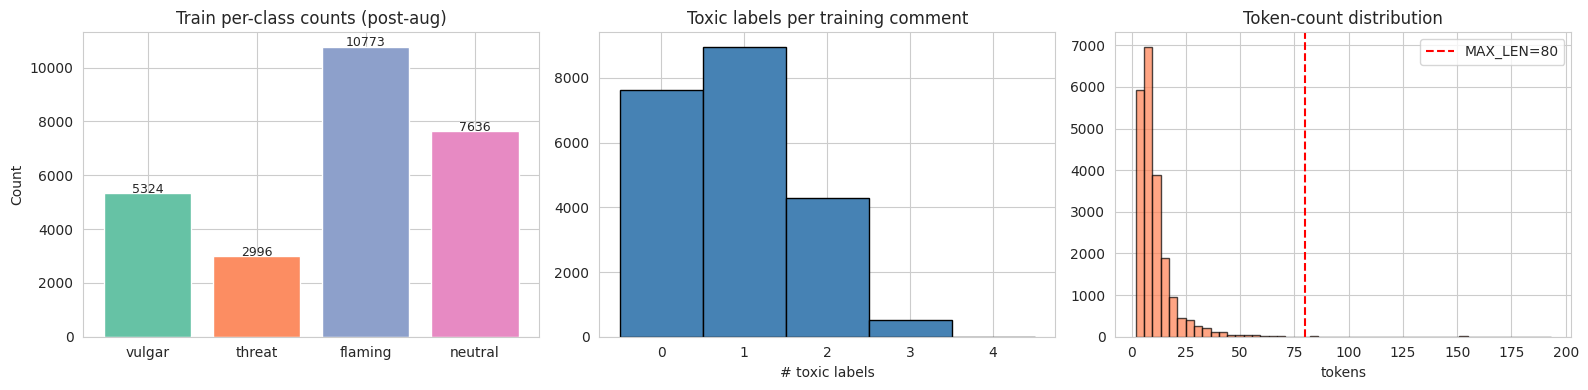

Train tokens: mean=10.5 median=8 max=193


In [6]:
# Section 8: Quick EDA (training split)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
counts = [int(df_train[c].sum()) for c in cfg.LABEL_COLS]
axes[0].bar(cfg.LABEL_COLS, counts, color=sns.color_palette('Set2', len(cfg.LABEL_COLS)))
axes[0].set_title('Train per-class counts (post-aug)'); axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)
labels_per = df_train[cfg.TOXIC_COLS].sum(axis=1)
axes[1].hist(labels_per, bins=range(0, 6), align='left', color='steelblue', edgecolor='black')
axes[1].set_title('Toxic labels per training comment'); axes[1].set_xlabel('# toxic labels')
wc = df_train['tokens'].apply(len)
axes[2].hist(wc, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[2].axvline(cfg.MAX_LEN, color='red', ls='--', label=f'MAX_LEN={cfg.MAX_LEN}')
axes[2].set_title('Token-count distribution'); axes[2].set_xlabel('tokens'); axes[2].legend()
plt.tight_layout(); plt.show()
print(f'Train tokens: mean={wc.mean():.1f} median={wc.median():.0f} max={wc.max()}')


In [7]:
# Section 9: Build Word + Character Vocabularies (ORIGINAL train text only)

def build_word_vocab(token_lists, min_freq=2, max_size=40000):
    counter = Counter()
    for toks in token_lists: counter.update(toks)
    words = [w for w, c in counter.most_common() if c >= min_freq][:max_size - 2]
    stoi = {'<PAD>': 0, '<UNK>': 1}
    for i, w in enumerate(words, start=2): stoi[w] = i
    return stoi, {v: k for k, v in stoi.items()}

def build_char_vocab(token_lists, max_size=300):
    counter = Counter()
    for toks in token_lists:
        for t in toks: counter.update(list(t))
    chars = [c for c, _ in counter.most_common(max_size - 2)]
    stoi = {'<PAD>': 0, '<UNK>': 1}
    for i, c in enumerate(chars, start=2): stoi[c] = i
    return stoi

vocab_df = df_train[df_train.get('is_aug', pd.Series(0, index=df_train.index)) == 0]
word_stoi, word_itos = build_word_vocab(vocab_df['tokens'].tolist(), cfg.MIN_FREQ, cfg.VOCAB_SIZE)
char_stoi = build_char_vocab(vocab_df['tokens'].tolist(), cfg.CHAR_VOCAB_SIZE)
VOCAB_SIZE = len(word_stoi)
CHAR_VOCAB_SIZE = len(char_stoi)
print(f'(vocab built on {len(vocab_df)} original train rows; full train = {len(df_train)})')

def encode_words(tokens, max_len):
    ids = [word_stoi.get(t, 1) for t in tokens[:max_len]]
    ids += [0] * (max_len - len(ids)); return ids

def encode_chars(tokens, max_len, max_char):
    result = []
    for t in tokens[:max_len]:
        cids = [char_stoi.get(c, 1) for c in t[:max_char]]
        cids += [0] * (max_char - len(cids)); result.append(cids)
    while len(result) < max_len: result.append([0]*max_char)
    return result

val_flat = [t for toks in df_val['tokens'] for t in toks]
oov = sum(1 for t in val_flat if t not in word_stoi) / max(1, len(val_flat)) * 100
print(f'Word vocab: {VOCAB_SIZE:,} | Char vocab: {CHAR_VOCAB_SIZE} | Val OOV: {oov:.2f}%')


(vocab built on 10705 original train rows; full train = 21407)
Word vocab: 8,162 | Char vocab: 78 | Val OOV: 15.62%


In [8]:
# Section 10: FastText Bengali embeddings (cc.bn.300)

FASTTEXT_URL = 'https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.bn.300.vec.gz'
FASTTEXT_LOCAL = 'cc.bn.300.vec.gz'
candidate_paths = [FASTTEXT_LOCAL, '/kaggle/input/fasttext-bengali/cc.bn.300.vec.gz',
                   os.path.expanduser('~/cc.bn.300.vec.gz')]
ft_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if ft_path is None:
    print('Downloading FastText Bengali vectors...')
    urllib.request.urlretrieve(FASTTEXT_URL, FASTTEXT_LOCAL); ft_path = FASTTEXT_LOCAL
print(f'Loading FastText from: {ft_path}')

pretrained = {}
with gzip.open(ft_path, 'rt', encoding='utf-8') as f:
    f.readline()
    for line in f:
        parts = line.rstrip().split(' ')
        w = parts[0]
        if w in word_stoi:
            vec = np.asarray(parts[1:], dtype=np.float32)
            if len(vec) == cfg.FASTTEXT_DIM: pretrained[w] = vec

embed_matrix = np.zeros((VOCAB_SIZE, cfg.FASTTEXT_DIM), dtype=np.float32)
scale = np.sqrt(3.0 / cfg.FASTTEXT_DIM)
for w, idx in word_stoi.items():
    if w in pretrained: embed_matrix[idx] = pretrained[w]
    elif idx > 1: embed_matrix[idx] = np.random.uniform(-scale, scale, cfg.FASTTEXT_DIM)

coverage = len(pretrained) / (VOCAB_SIZE - 2) * 100
print(f'FastText coverage: {len(pretrained)}/{VOCAB_SIZE-2} ({coverage:.1f}%)')
embed_matrix_tensor = torch.FloatTensor(embed_matrix)
del pretrained, embed_matrix


Loading FastText from: cc.bn.300.vec.gz
FastText coverage: 7846/8160 (96.2%)


In [9]:
# Section 11: Dataset & DataLoaders (model targets = 4 toxic labels)

class BengaliCBDataset(Dataset):
    def __init__(self, df, cfg, is_train=False):
        self.texts = df['tokens'].tolist()
        self.labels = df[cfg.TOXIC_COLS].values.astype(np.float32)
        self.cfg = cfg; self.is_train = is_train
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        tokens = self.texts[idx]
        if self.is_train and self.cfg.WORD_DROPOUT_P > 0:
            tokens = [t if random.random() > self.cfg.WORD_DROPOUT_P else '<UNK>' for t in tokens]
        word_ids = encode_words(tokens, self.cfg.MAX_LEN)
        char_ids = encode_chars(tokens, self.cfg.MAX_LEN, self.cfg.MAX_CHAR_PER_WORD)
        return (torch.LongTensor(word_ids), torch.LongTensor(char_ids),
                torch.FloatTensor(self.labels[idx]))

train_ds = BengaliCBDataset(df_train, cfg, is_train=True)
val_ds   = BengaliCBDataset(df_val, cfg, is_train=False)
test_ds  = BengaliCBDataset(df_test, cfg, is_train=False)
train_loader = DataLoader(train_ds, batch_size=EFFECTIVE_BATCH, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=EFFECTIVE_BATCH*2, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=EFFECTIVE_BATCH*2, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')


Train batches: 167 | Val: 9 | Test: 9


In [10]:
# Section 12: Model (CharCNN + FastText + TextCNN + BiGRU + Attention)

class SpatialDropout1D(nn.Module):
    def __init__(self, p): super().__init__(); self.p = p
    def forward(self, x):
        if not self.training or self.p == 0: return x
        mask = x.new_ones(x.size(0), 1, x.size(2))
        mask = F.dropout(mask, p=self.p, training=True)
        return x * mask

class CharCNN(nn.Module):
    def __init__(self, cfg, char_vocab_size):
        super().__init__()
        self.char_embed = nn.Embedding(char_vocab_size, cfg.CHAR_EMBED_DIM, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(cfg.CHAR_EMBED_DIM, cfg.CHAR_CNN_FILTERS, k, padding=k//2) for k in cfg.CHAR_KERNELS])
        self.out_dim = cfg.CHAR_CNN_FILTERS * len(cfg.CHAR_KERNELS)
    def forward(self, x):
        B, S, C = x.shape
        x = x.view(B*S, C)
        x = self.char_embed(x).permute(0, 2, 1)
        outs = [F.relu(conv(x)).max(dim=2)[0] for conv in self.convs]
        return torch.cat(outs, dim=1).view(B, S, -1)

class AdditiveAttention(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.W = nn.Linear(hidden, hidden); self.v = nn.Linear(hidden, 1, bias=False)
    def forward(self, h, mask=None):
        energy = torch.tanh(self.W(h))
        scores = self.v(energy).squeeze(-1)
        if mask is not None: scores = scores.masked_fill(mask == 0, -1e9)
        attn = F.softmax(scores, dim=1)
        return torch.bmm(attn.unsqueeze(1), h).squeeze(1), attn

class V8Model(nn.Module):
    def __init__(self, cfg, embed_matrix, vocab_size, char_vocab_size):
        super().__init__(); self.cfg = cfg
        self.char_cnn = CharCNN(cfg, char_vocab_size)
        self.word_embed = nn.Embedding(vocab_size, cfg.FASTTEXT_DIM, padding_idx=0)
        if embed_matrix is not None: self.word_embed.weight.data.copy_(embed_matrix)
        if cfg.FREEZE_EMBEDDING: self.word_embed.weight.requires_grad = False
        self.projection = nn.Linear(cfg.FASTTEXT_DIM, cfg.PROJECTION_DIM)
        self.spatial_drop = SpatialDropout1D(cfg.DROPOUT_EMB)
        combined = cfg.PROJECTION_DIM + self.char_cnn.out_dim
        self.text_convs = nn.ModuleList([
            nn.Conv1d(combined, cfg.CNN_FILTERS, k, padding=k//2) for k in cfg.CNN_KERNELS])
        cnn_out = cfg.CNN_FILTERS * len(cfg.CNN_KERNELS)
        self.gru = nn.GRU(cnn_out, cfg.GRU_HIDDEN, num_layers=cfg.GRU_LAYERS,
                          batch_first=True, bidirectional=True,
                          dropout=cfg.DROPOUT if cfg.GRU_LAYERS > 1 else 0)
        gru_out = cfg.GRU_HIDDEN * 2
        self.attention = AdditiveAttention(gru_out)
        self.dropouts = nn.ModuleList([nn.Dropout(cfg.DROPOUT) for _ in range(cfg.NUM_DROPOUT_SAMPLES)])
        self.fc1 = nn.Linear(gru_out * 3, cfg.FC_HIDDEN)
        self.fc2 = nn.Linear(cfg.FC_HIDDEN, cfg.NUM_OUT)
        self._init_weights()
    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'word_embed' in name: continue
            if 'weight' in name and p.dim() >= 2: nn.init.xavier_uniform_(p)
            elif 'bias' in name: nn.init.zeros_(p)
    def forward(self, word_ids, char_ids):
        word_proj = F.relu(self.projection(self.word_embed(word_ids)))
        char_feat = self.char_cnn(char_ids)
        x = torch.cat([word_proj, char_feat], dim=2)
        x = self.spatial_drop(x).permute(0, 2, 1)
        conv_outs = [F.relu(conv(x)).permute(0, 2, 1) for conv in self.text_convs]
        if len({t.size(1) for t in conv_outs}) != 1:
            m = min(t.size(1) for t in conv_outs); conv_outs = [t[:, :m, :] for t in conv_outs]
        x = torch.cat(conv_outs, dim=2)
        gru_out, _ = self.gru(x)
        mask = (word_ids != 0).float()
        attn_ctx, _ = self.attention(gru_out, mask)
        max_pool = gru_out.max(dim=1)[0]
        avg_pool = (gru_out * mask.unsqueeze(2)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1)
        feats = torch.cat([attn_ctx, max_pool, avg_pool], dim=1)
        if self.training:
            logits = torch.stack([self.fc2(F.relu(self.fc1(drop(feats)))) for drop in self.dropouts], 0).mean(0)
        else:
            logits = self.fc2(F.relu(self.fc1(feats)))
        return logits

set_seed(SEED)
model = V8Model(cfg, embed_matrix_tensor, VOCAB_SIZE, CHAR_VOCAB_SIZE)
total_params = sum(p.numel() for p in model.parameters())
embed_params = cfg.FASTTEXT_DIM * VOCAB_SIZE
print('=' * 60)
print('              PARAMETER COUNT')
print('=' * 60)
print(f'  Word embedding (FastText): {embed_params:>12,}')
print(f'  Rest of the network:       {total_params-embed_params:>12,}')
print(f'  TOTAL parameters:          {total_params:>12,} ({total_params/1e6:.2f}M)')
print('=' * 60)

if NUM_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'Wrapped with nn.DataParallel across {NUM_GPUS} GPUs (T4 x2).')
model = model.to(device)


              PARAMETER COUNT
  Word embedding (FastText):    2,448,600
  Rest of the network:          7,576,099
  TOTAL parameters:            10,024,699 (10.02M)
Wrapped with nn.DataParallel across 2 GPUs (T4 x2).


In [11]:
# Section 13: Focal Loss (no pos_weight) + base optimizer/scheduler factory

class FocalBCELoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None, smoothing=0.0):
        super().__init__()
        self.gamma = gamma; self.pos_weight = pos_weight; self.smoothing = smoothing
    def forward(self, logits, targets):
        if self.smoothing > 0:
            targets = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none', pos_weight=self.pos_weight)
        probs = torch.sigmoid(logits)
        p_t = targets * probs + (1 - targets) * (1 - probs)
        return ((1 - p_t) ** self.gamma * bce).mean()

criterion = FocalBCELoss(cfg.FOCAL_GAMMA, None, cfg.LABEL_SMOOTHING) if cfg.USE_FOCAL_LOSS else nn.BCEWithLogitsLoss()
print(f'Loss: {"Focal" if cfg.USE_FOCAL_LOSS else "BCE"} (gamma={cfg.FOCAL_GAMMA}, smoothing={cfg.LABEL_SMOOTHING}) | pos_weight DISABLED')

total_steps = cfg.EPOCHS * len(train_loader)
warmup_steps = int(total_steps * cfg.WARMUP_RATIO)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))

print(f'Total steps: {total_steps} | Warmup: {warmup_steps}')


Loss: Focal (gamma=2.0, smoothing=0.05) | pos_weight DISABLED
Total steps: 5845 | Warmup: 584


In [12]:
# Section 14: Train/eval helpers + SWA, then train the main (seed 42) model

def neutral_from_toxic(binary_toxic):
    neu = (binary_toxic.sum(axis=1) == 0).astype(int).reshape(-1, 1)
    return np.concatenate([binary_toxic, neu], axis=1)

def make_unfreeze_optimizer(m, cfg):
    base = m.module if hasattr(m, 'module') else m
    base.word_embed.weight.requires_grad = True
    embed_p = [base.word_embed.weight]
    other_p = [p for n, p in base.named_parameters() if 'word_embed' not in n and p.requires_grad]
    return AdamW([
        {'params': embed_p, 'lr': cfg.LR * cfg.UNFREEZE_EMB_LR_FACTOR},
        {'params': other_p, 'lr': cfg.LR * cfg.UNFREEZE_BODY_LR_FACTOR}], weight_decay=cfg.WEIGHT_DECAY)

def swa_accumulate(swa_state, m, n):
    msd = (m.module if hasattr(m, 'module') else m).state_dict()
    if swa_state is None:
        return {k: v.detach().clone().float() for k, v in msd.items()}, 1
    for k in swa_state:
        swa_state[k].mul_(n / (n + 1.0)).add_(msd[k].detach().float() / (n + 1.0))
    return swa_state, n + 1

def train_one_epoch(m, loader, criterion, optimizer, scheduler, global_step):
    m.train(); total_loss = 0.0; preds_all, labels_all = [], []
    for word_ids, char_ids, labels in loader:
        word_ids = word_ids.to(device); char_ids = char_ids.to(device); labels = labels.to(device)
        optimizer.zero_grad()
        logits = m(word_ids, char_ids)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, m.parameters()), cfg.GRAD_CLIP)
        optimizer.step(); scheduler.step(); global_step += 1
        total_loss += loss.item()
        preds_all.append(torch.sigmoid(logits).detach().cpu().numpy())
        labels_all.append(labels.detach().cpu().numpy())
    preds_all = np.vstack(preds_all); labels_all = np.vstack(labels_all)
    f1 = f1_score((labels_all > 0.5).astype(int), (preds_all > 0.5).astype(int), average='macro', zero_division=0)
    return total_loss / len(loader), f1, global_step

@torch.no_grad()
def evaluate(m, loader, criterion):
    m.eval(); total_loss = 0.0; preds_all, labels_all = [], []
    for word_ids, char_ids, labels in loader:
        word_ids = word_ids.to(device); char_ids = char_ids.to(device); labels = labels.to(device)
        logits = m(word_ids, char_ids)
        total_loss += criterion(logits, labels).item()
        preds_all.append(torch.sigmoid(logits).cpu().numpy())
        labels_all.append(labels.cpu().numpy())
    preds_all = np.vstack(preds_all); labels_all = np.vstack(labels_all)
    bin_pred5 = neutral_from_toxic((preds_all > 0.5).astype(int))
    bin_true5 = neutral_from_toxic((labels_all > 0.5).astype(int))
    macro_f1 = f1_score(bin_true5, bin_pred5, average='macro', zero_division=0)
    per_class = f1_score(bin_true5, bin_pred5, average=None, zero_division=0)
    return total_loss / len(loader), macro_f1, per_class, preds_all, labels_all

def fit_model(seed, collect_history=False, verbose=True):
    set_seed(seed)
    m = V8Model(cfg, embed_matrix_tensor, VOCAB_SIZE, CHAR_VOCAB_SIZE)
    if NUM_GPUS > 1: m = nn.DataParallel(m)
    m = m.to(device)
    base = m.module if hasattr(m, 'module') else m
    optimizer = AdamW(filter(lambda p: p.requires_grad, m.parameters()), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = LambdaLR(optimizer, lr_lambda)
    hist = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': [], 'val_per_class_f1': [], 'lr': []}
    best_val_f1, best_epoch, patience, gstep, best_state = 0.0, 0, 0, 0, None
    swa_state, swa_n = None, 0
    swa_start = cfg.UNFREEZE_AT_EPOCH + cfg.SWA_START_OFFSET
    for epoch in range(1, cfg.EPOCHS + 1):
        t0 = time.time()
        if epoch == cfg.UNFREEZE_AT_EPOCH:
            optimizer = make_unfreeze_optimizer(m, cfg)
            remaining = (cfg.EPOCHS - epoch + 1) * len(train_loader)
            scheduler = LambdaLR(optimizer, lambda s: 0.5 * (1.0 + math.cos(math.pi * min(1.0, s / remaining))))
            if verbose: print(f'  >> Unfroze embeddings at epoch {epoch} (body LR {cfg.LR*cfg.UNFREEZE_BODY_LR_FACTOR:.1e}, embed LR {cfg.LR*cfg.UNFREEZE_EMB_LR_FACTOR:.1e})')
        phase = 'Frozen' if epoch < cfg.UNFREEZE_AT_EPOCH else 'Unfrozen'
        train_loss, train_f1, gstep = train_one_epoch(m, train_loader, criterion, optimizer, scheduler, gstep)
        val_loss, val_f1, val_pc, _, _ = evaluate(m, val_loader, criterion)
        if cfg.USE_SWA and epoch >= swa_start:
            swa_state, swa_n = swa_accumulate(swa_state, m, swa_n)
        if collect_history:
            for k, v in [('train_loss', train_loss), ('val_loss', val_loss), ('train_f1', train_f1),
                         ('val_f1', val_f1), ('val_per_class_f1', val_pc.tolist()), ('lr', optimizer.param_groups[-1]['lr'])]:
                hist[k].append(v)
        if val_f1 > best_val_f1:
            best_val_f1, best_epoch = val_f1, epoch
            best_state = copy.deepcopy(base.state_dict()); patience = 0; marker = ' *BEST*'
        else:
            patience += 1; marker = ''
        if verbose:
            print(f'Epoch {epoch:02d}/{cfg.EPOCHS} [{phase:>8s}] TrLoss {train_loss:.4f} VaLoss {val_loss:.4f} '
                  f'TrF1 {train_f1:.4f} VaF1 {val_f1:.4f} Gap {train_f1-val_f1:+.4f} {time.time()-t0:.0f}s{marker}')
        if patience >= cfg.PATIENCE:
            if verbose: print(f'Early stopping at epoch {epoch} (patience={cfg.PATIENCE}).'); 
            break
    # --- choose best-single vs SWA on validation ---
    base.load_state_dict(best_state)
    chosen = f'best-single (epoch {best_epoch})'
    chosen_val_f1 = best_val_f1
    if cfg.USE_SWA and swa_state is not None:
        _, swa_val_f1, _, _, _ = evaluate_state(m, base, swa_state)
        if swa_val_f1 >= best_val_f1:
            base.load_state_dict({k: v for k, v in swa_state.items()})
            chosen = f'SWA (avg of {swa_n} epochs)'; chosen_val_f1 = swa_val_f1
        if verbose:
            print(f'SWA val {swa_val_f1:.4f} vs best-single {best_val_f1:.4f} -> using {chosen}')
    vp, _ = predict_probs(m, val_loader)
    tp, _ = predict_probs(m, test_loader)
    return {'model': m, 'val_probs': vp, 'test_probs': tp, 'val_f1': chosen_val_f1,
            'best_epoch': best_epoch, 'history': hist, 'chosen': chosen}

@torch.no_grad()
def evaluate_state(m, base, state):
    saved = copy.deepcopy(base.state_dict())
    base.load_state_dict({k: v for k, v in state.items()})
    out = evaluate(m, val_loader, criterion)
    base.load_state_dict(saved)
    return out

@torch.no_grad()
def predict_probs(m, loader):
    m.eval(); probs, labels = [], []
    for word_ids, char_ids, y in loader:
        logits = m(word_ids.to(device), char_ids.to(device))
        probs.append(torch.sigmoid(logits).cpu().numpy()); labels.append(y.numpy())
    return np.vstack(probs), np.vstack(labels)

print(f'Training main model (seed {SEED}) | SWA={cfg.USE_SWA}')
print('=' * 95)
main = fit_model(SEED, collect_history=True, verbose=True)
model = main['model']; history = main['history']; best_val_f1 = main['val_f1']; best_epoch = main['best_epoch']
print('=' * 95)
print(f"Main model ready -> {main['chosen']} | Val Macro-F1 {best_val_f1:.4f}")


Training main model (seed 42) | SWA=True
Epoch 01/35 [  Frozen] TrLoss 0.1411 VaLoss 0.1254 TrF1 0.2442 VaF1 0.4956 Gap -0.2515 19s *BEST*
Epoch 02/35 [  Frozen] TrLoss 0.1169 VaLoss 0.0991 TrF1 0.5145 VaF1 0.6937 Gap -0.1793 17s *BEST*
Epoch 03/35 [  Frozen] TrLoss 0.1043 VaLoss 0.0929 TrF1 0.6201 VaF1 0.7180 Gap -0.0979 17s *BEST*
Epoch 04/35 [  Frozen] TrLoss 0.0963 VaLoss 0.0896 TrF1 0.6664 VaF1 0.7295 Gap -0.0631 18s *BEST*
Epoch 05/35 [  Frozen] TrLoss 0.0919 VaLoss 0.0803 TrF1 0.6898 VaF1 0.7559 Gap -0.0661 18s *BEST*
  >> Unfroze embeddings at epoch 6 (body LR 2.4e-04, embed LR 4.0e-05)
Epoch 06/35 [Unfrozen] TrLoss 0.0847 VaLoss 0.0787 TrF1 0.7289 VaF1 0.7652 Gap -0.0363 19s *BEST*
Epoch 07/35 [Unfrozen] TrLoss 0.0800 VaLoss 0.0793 TrF1 0.7452 VaF1 0.7682 Gap -0.0230 19s *BEST*
Epoch 08/35 [Unfrozen] TrLoss 0.0768 VaLoss 0.0774 TrF1 0.7628 VaF1 0.7735 Gap -0.0107 19s *BEST*
Epoch 09/35 [Unfrozen] TrLoss 0.0734 VaLoss 0.0761 TrF1 0.7785 VaF1 0.7772 Gap +0.0013 19s *BEST*
Epoch 

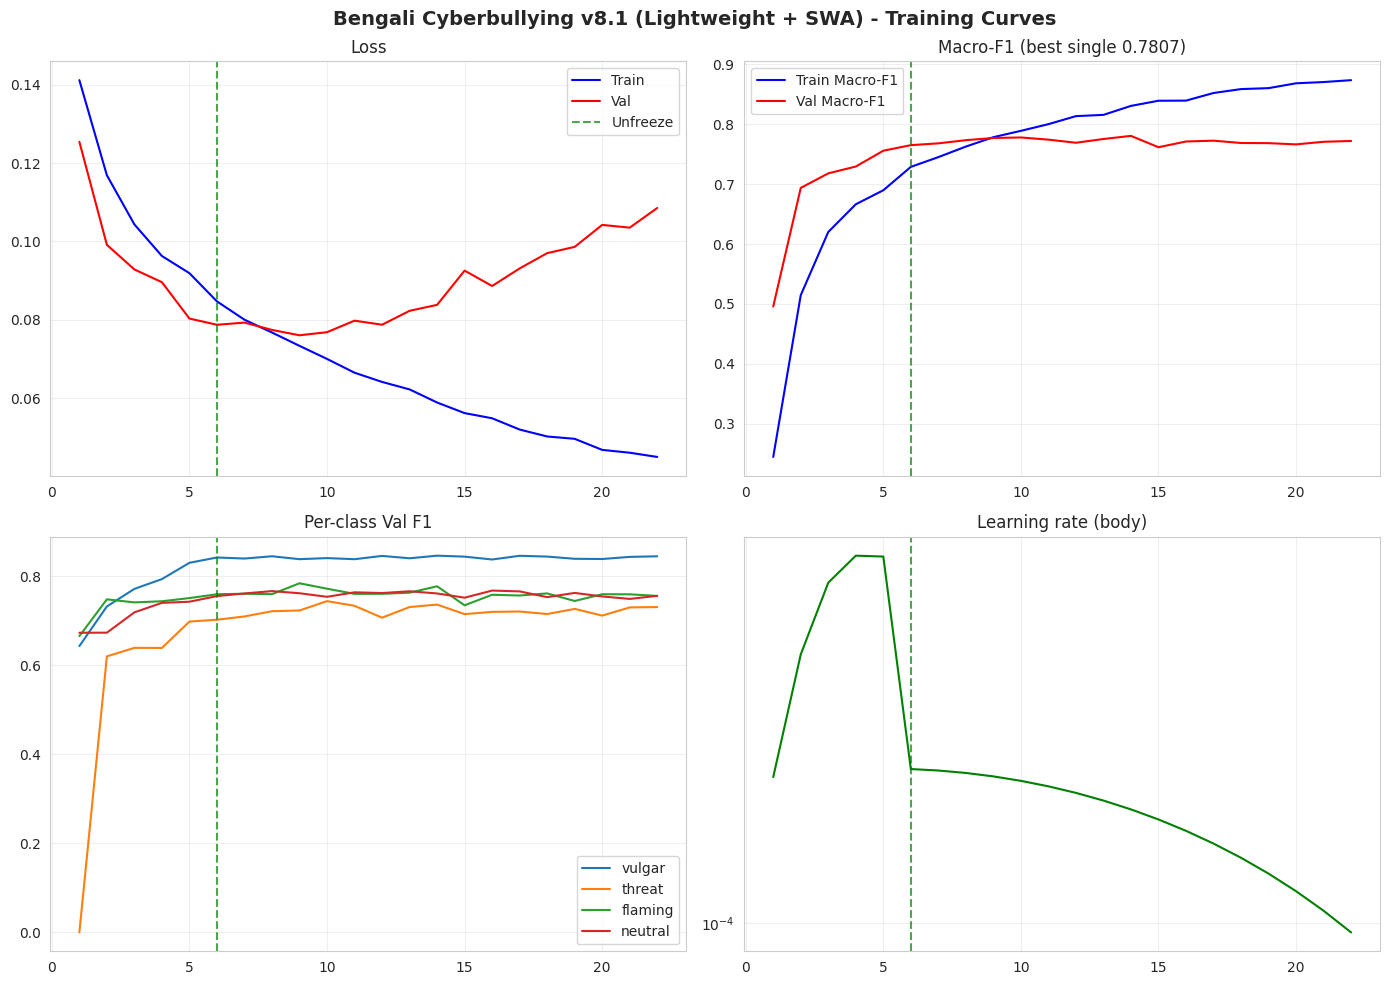

In [13]:
# Section 15: Training curves (main model)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ep = range(1, len(history['train_loss']) + 1)
uf = cfg.UNFREEZE_AT_EPOCH
axes[0,0].plot(ep, history['train_loss'], 'b-', label='Train'); axes[0,0].plot(ep, history['val_loss'], 'r-', label='Val')
if uf <= len(ep): axes[0,0].axvline(uf, color='green', ls='--', alpha=0.7, label='Unfreeze')
axes[0,0].set_title('Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
axes[0,1].plot(ep, history['train_f1'], 'b-', label='Train Macro-F1'); axes[0,1].plot(ep, history['val_f1'], 'r-', label='Val Macro-F1')
if uf <= len(ep): axes[0,1].axvline(uf, color='green', ls='--', alpha=0.7)
axes[0,1].set_title(f'Macro-F1 (best single {max(history["val_f1"]):.4f})'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
pc = np.array(history['val_per_class_f1'])
for i, c in enumerate(cfg.LABEL_COLS):
    axes[1,0].plot(ep, pc[:, i], '-', label=c, lw=1.5)
if uf <= len(ep): axes[1,0].axvline(uf, color='green', ls='--', alpha=0.7)
axes[1,0].set_title('Per-class Val F1'); axes[1,0].legend(loc='lower right'); axes[1,0].grid(alpha=0.3)
axes[1,1].plot(ep, history['lr'], 'g-'); axes[1,1].set_yscale('log')
if uf <= len(ep): axes[1,1].axvline(uf, color='green', ls='--', alpha=0.7)
axes[1,1].set_title('Learning rate (body)'); axes[1,1].grid(alpha=0.3)
plt.suptitle('Bengali Cyberbullying v8.1 (Lightweight + SWA) - Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('v8_training_curves.png', dpi=150, bbox_inches='tight'); plt.show()


In [14]:
# Section 16: Per-class threshold tuning on the (clean) validation set

val_preds = main['val_probs']
_, _, _, _, val_labels = evaluate(model, val_loader, criterion)

def tune_thresholds(preds, labels, cfg):
    grid = np.arange(cfg.THRESH_MIN, cfg.THRESH_MAX + 1e-9, cfg.THRESH_STEP)
    best = np.full(preds.shape[1], 0.5)
    for c in range(preds.shape[1]):
        bf = -1.0
        for t in grid:
            f1 = f1_score(labels[:, c], (preds[:, c] > t).astype(int), zero_division=0)
            if f1 > bf: bf, best[c] = f1, t
    return best

tuned = tune_thresholds(val_preds, val_labels, cfg)
print('Tuned thresholds (toxic classes):')
for c, t in zip(cfg.TOXIC_COLS, tuned): print(f'  {c:>8s}: {t:.2f}')

def apply_thresholds(preds, thresholds):
    out = np.zeros_like(preds)
    for c in range(preds.shape[1]): out[:, c] = (preds[:, c] > thresholds[c]).astype(int)
    return out

def to5(binary_toxic):
    neu = (binary_toxic.sum(axis=1) == 0).astype(int).reshape(-1, 1)
    return np.concatenate([binary_toxic, neu], axis=1)


Tuned thresholds (toxic classes):
    vulgar: 0.56
    threat: 0.52
   flaming: 0.44


In [15]:
# Section 17: Final test evaluation (single model; derive neutral, all 5 classes)

def report5(true5, pred5, probs5, title):
    macro = f1_score(true5, pred5, average='macro', zero_division=0)
    micro = f1_score(true5, pred5, average='micro', zero_division=0)
    weighted = f1_score(true5, pred5, average='weighted', zero_division=0)
    h = hamming_loss(true5, pred5)
    try: roc = roc_auc_score(true5, probs5, average='macro')
    except ValueError: roc = float('nan')
    print('=' * 64); print(f'   {title}'); print('=' * 64)
    print(f'  Macro-F1: {macro:.4f} | Micro-F1: {micro:.4f} | Weighted-F1: {weighted:.4f} | Hamming: {h:.4f} | ROC-AUC: {roc:.4f}')
    print(classification_report(true5, pred5, target_names=cfg.LABEL_COLS, digits=4, zero_division=0))
    return macro

_, test_toxic_labels = predict_probs(model, test_loader)
test_probs = main['test_probs']
test_pred5 = to5(apply_thresholds(test_probs, tuned))
test_true5 = to5((test_toxic_labels > 0.5).astype(int))
test_probs5 = np.concatenate([test_probs, 1.0 - test_probs.max(axis=1, keepdims=True)], axis=1)
macro_f1 = report5(test_true5, test_pred5, test_probs5, 'FINAL TEST (single model, seed 42, SWA-selected)')
print(f'Total params: {total_params:,} ({total_params/1e6:.2f}M)')


   FINAL TEST (single model, seed 42, SWA-selected)
  Macro-F1: 0.7799 | Micro-F1: 0.7837 | Weighted-F1: 0.7826 | Hamming: 0.1363 | ROC-AUC: 0.9219
              precision    recall  f1-score   support

      vulgar     0.9175    0.7807    0.8436       570
      threat     0.7297    0.7570    0.7431       321
     flaming     0.7174    0.8951    0.7965      1154
     neutral     0.8277    0.6630    0.7363       819

   micro avg     0.7769    0.7905    0.7837      2864
   macro avg     0.7981    0.7740    0.7799      2864
weighted avg     0.7902    0.7905    0.7826      2864
 samples avg     0.7683    0.7778    0.7625      2864

Total params: 10,024,699 (10.02M)


## Section 18: Multi-seed ensemble (runs by default) — the headline result

Each seed is trained with the same SWA selection, then toxic probabilities are averaged, thresholds
re-tuned on the averaged validation probabilities, and the ensembled test score reported.


In [ ]:
# Section 19: Multi-seed ensemble (default ON; each member uses SWA selection)

ensemble_macro = macro_f1
if cfg.RUN_ENSEMBLE:
    print(f'Training ensemble seeds {cfg.ENSEMBLE_SEEDS} (each is a full model; uses SWA selection)...')
    results = []
    for s in cfg.ENSEMBLE_SEEDS:
        if s == SEED:
            results.append(main)  # reuse the already-trained main model
            print(f'  seed {s}: reused main model (val {main["val_f1"]:.4f}, {main["chosen"]})')
        else:
            r = fit_model(s, collect_history=False, verbose=False)
            results.append(r)
            print(f'  seed {s}: val {r["val_f1"]:.4f} ({r["chosen"]})')
    val_avg = np.mean([r['val_probs'] for r in results], axis=0)
    test_avg = np.mean([r['test_probs'] for r in results], axis=0)
    ens_thresh = tune_thresholds(val_avg, val_labels, cfg)
    print('Ensemble tuned thresholds:', {c: round(float(t),2) for c,t in zip(cfg.TOXIC_COLS, ens_thresh)})
    ens_pred5 = to5(apply_thresholds(test_avg, ens_thresh))
    ens_probs5 = np.concatenate([test_avg, 1.0 - test_avg.max(axis=1, keepdims=True)], axis=1)
    ensemble_macro = report5(test_true5, ens_pred5, ens_probs5, f'FINAL TEST (ENSEMBLE of {len(cfg.ENSEMBLE_SEEDS)} seeds + SWA)')
    print(f'Single-model Macro-F1: {macro_f1:.4f}  ->  Ensemble Macro-F1: {ensemble_macro:.4f}  (+{(ensemble_macro-macro_f1)*100:.2f}%)')
else:
    print('RUN_ENSEMBLE is False; ensemble skipped.')


Training ensemble seeds [42, 7, 2024] (each is a full model; uses SWA selection)...
  seed 42: reused main model (val 0.7807, best-single (epoch 14))
  seed 7: val 0.7854 (best-single (epoch 11))


In [ ]:
# Section 20: Save checkpoint + summary

base_model = model.module if hasattr(model, 'module') else model
torch.save({
    'model_state_dict': base_model.state_dict(),
    'config': {k: v for k, v in vars(cfg).items() if not k.startswith('_')},
    'thresholds': tuned.tolist(), 'toxic_cols': cfg.TOXIC_COLS,
    'best_epoch': best_epoch, 'best_val_f1': best_val_f1,
    'test_macro_f1': macro_f1, 'total_params': total_params,
}, 'bengali_cyberbullying_v8_lightweight.pt')

summary = {
    'version': 'v8.1-lightweight-swa',
    'total_params': int(total_params), 'total_params_millions': round(total_params/1e6, 3),
    'predicts': cfg.TOXIC_COLS, 'neutral': 'derived as NOT(any toxic)',
    'train_size': len(df_train), 'val_size': len(df_val), 'test_size': len(df_test),
    'best_epoch': best_epoch, 'best_val_macro_f1': round(float(best_val_f1), 4),
    'test_macro_f1_single': round(float(macro_f1), 4),
    'test_macro_f1_ensemble': round(float(ensemble_macro), 4),
    'tuned_thresholds': dict(zip(cfg.TOXIC_COLS, [round(float(t),2) for t in tuned])),
    'techniques': ['balance-preserving augmentation', 'lower post-unfreeze LR',
                   'SWA weight averaging (val-selected)', 'multi-seed ensemble'],
}
with open('v8_summary.json', 'w') as f: json.dump(summary, f, indent=2, ensure_ascii=False)
print('Saved checkpoint + v8_summary.json')
print(f'\nFINAL: single={macro_f1:.4f} | ensemble={ensemble_macro:.4f} | Params={total_params:,} ({total_params/1e6:.2f}M)')


## Section 21: Notes

- **SWA** averages the weights over the post-unfreeze plateau and is kept only if it beats the best
  single epoch on validation, so it cannot hurt. It usually transfers to the test set better than a
  single spiky peak epoch (which was the v8 symptom).
- **Headline = ensemble** (Section 19): 3 seeds, each SWA-selected, probabilities averaged.
- This from-scratch model is data/label-limited (`troll`/`insult` overlap); realistic best ~0.73-0.75.
  The transformer notebook is where ~0.80 lives.
- To run a single fast model, set `cfg.RUN_ENSEMBLE=False`. To disable SWA, `cfg.USE_SWA=False`.
